In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal =sns.color_palette()
plt.style.use('fivethirtyeight')

**Types of Time Serires Data**

In [2]:
df=pd.read_csv('/content/PJMW_hourly.csv')
df=df.set_index('Datetime')
df.index=pd.to_datetime(df.index)
df.head()

,PJMW_MW
Datetime,
2002-12-31 01:00:00,5077.0
2002-12-31 02:00:00,4939.0
2002-12-31 03:00:00,4885.0
2002-12-31 04:00:00,4857.0
2002-12-31 05:00:00,4930.0


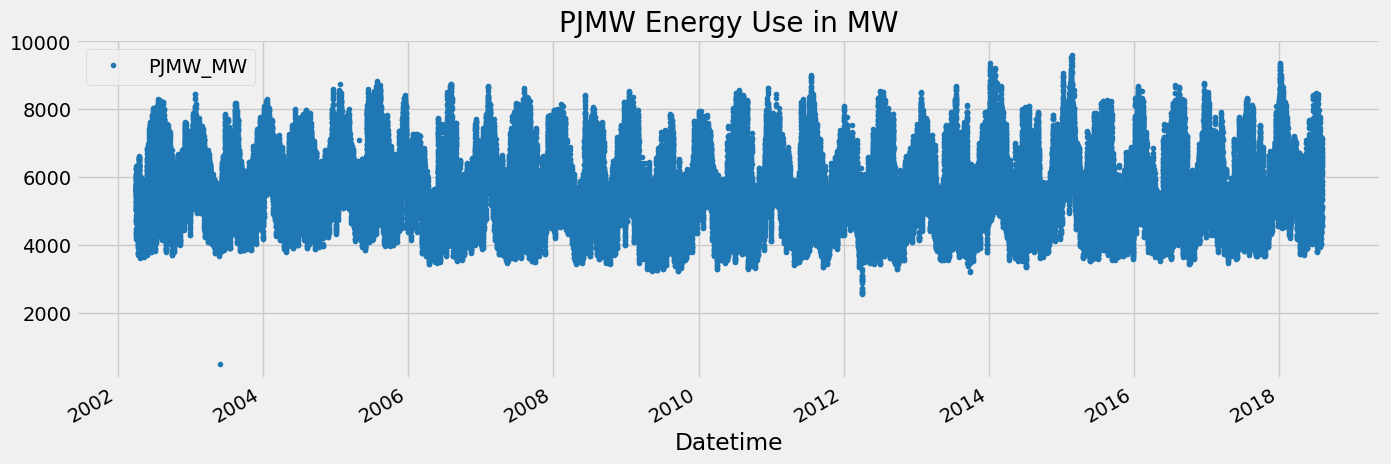

In [3]:
df.plot(style='.',figsize=(15,5),color=color_pal[0],title='PJMW Energy Use in MW')
plt.show()

**Train/Test Split**

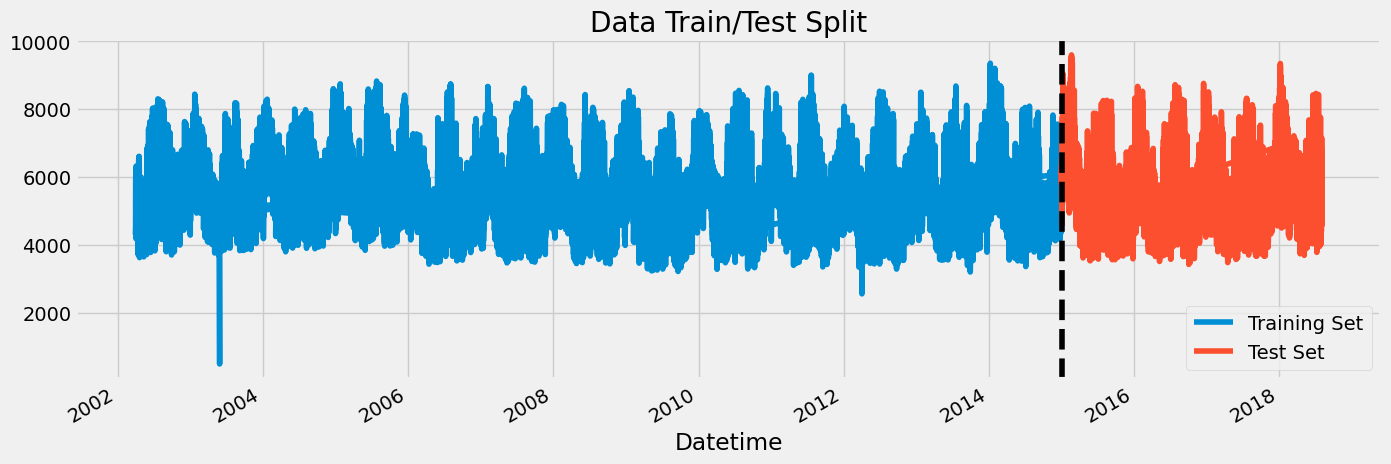

In [6]:
train=df.loc[df.index<'01-01-2015']
test=df.loc[df.index>='01-01-2015']
fig,ax=plt.subplots(figsize=(15,5))
train.plot(ax=ax,label='Training Set',title='Data Train/Test Split')
test.plot(ax=ax,label='Test Set')
ax.axvline('01-01-2015',color='black',linestyle='--')
ax.legend(['Training Set','Test Set'])
plt.show()

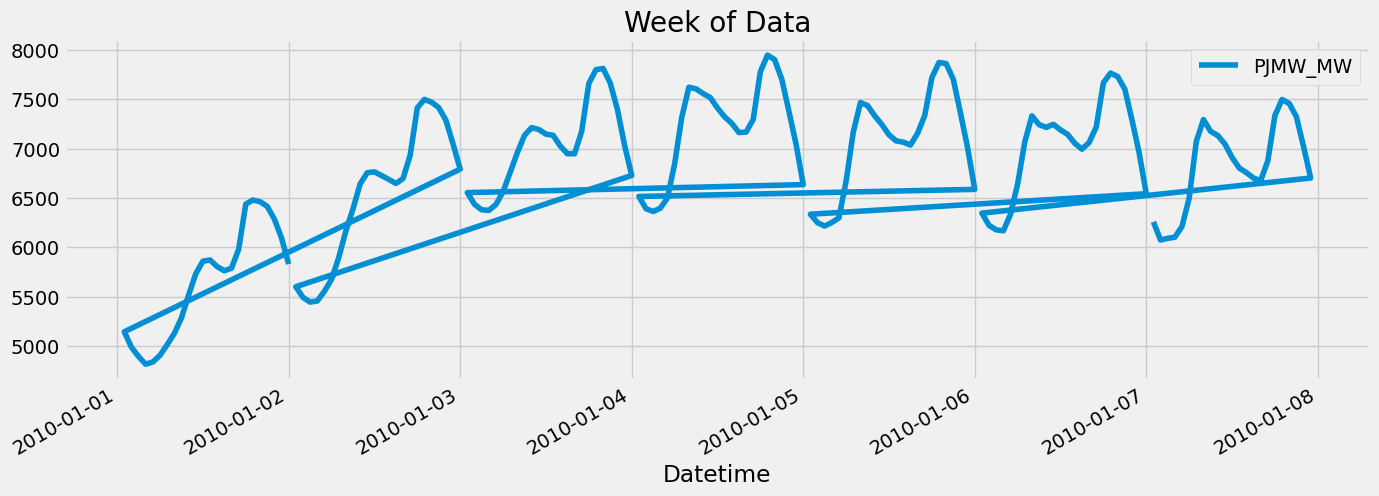

In [9]:
df.loc[(df.index >'01-01-2010')&(df.index <'01-08-2010')]\
     .plot(figsize=(15,5),title='Week of Data')
plt.show()

**Feature Creation**

In [11]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df=df.copy()
    df['hour']=df.index.hour
    df['dayofweek']=df.index.dayofweek
    df['quarter']=df.index.quarter
    df['month']=df.index.month
    df['year']=df.index.year
    df['dayofyear']=df.index.dayofyear
    df['dayofmonth']=df.index.day
    df['weekofyear']=df.index.isocalendar().week
    return df
df=create_features(df)

**Target Relationship**

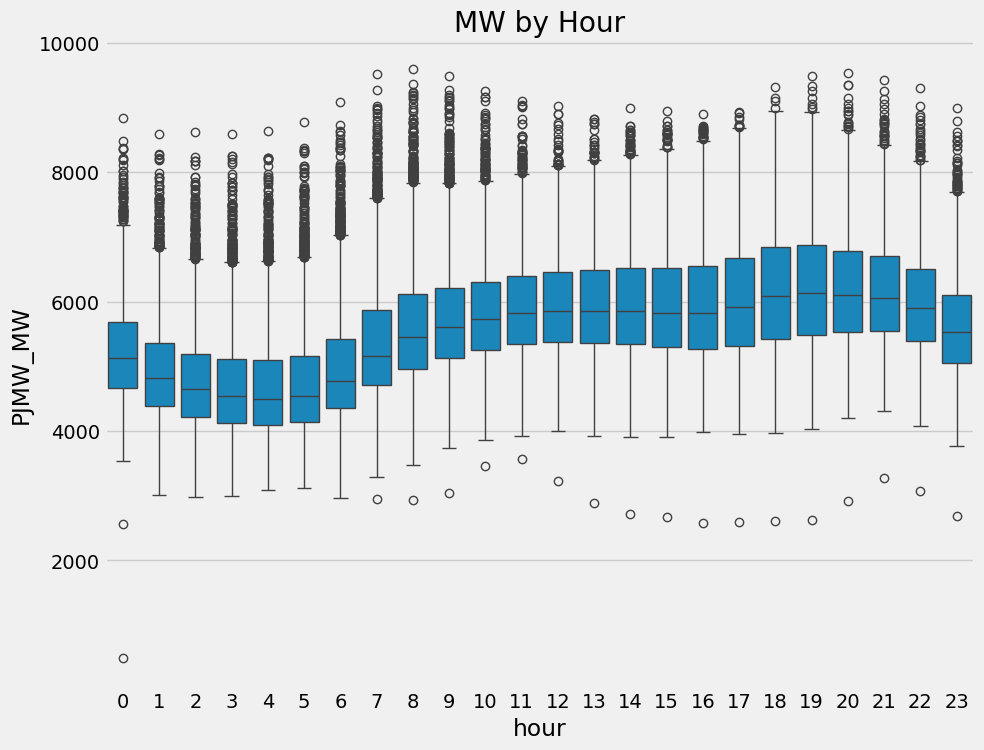

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJMW_MW')
ax.set_title('MW by Hour')
plt.show()

Create Our Model

In [13]:
train = create_features(train)
test = create_features(test)
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'PJMW_MW'
X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

In [15]:
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3, learning_rate=0.01)
reg.fit(X_train,y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:5625.61344	validation_1-rmse:5649.37258


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:02:48] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:2153.59860	validation_1-rmse:2186.32198
[200]	validation_0-rmse:973.62599	validation_1-rmse:1047.24441
[300]	validation_0-rmse:640.09790	validation_1-rmse:752.64687
[400]	validation_0-rmse:553.62288	validation_1-rmse:682.60497
[500]	validation_0-rmse:525.89564	validation_1-rmse:665.80593
[600]	validation_0-rmse:511.06594	validation_1-rmse:660.03348
[700]	validation_0-rmse:500.50703	validation_1-rmse:657.99281
[770]	validation_0-rmse:495.24782	validation_1-rmse:657.68052


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, objective='reg:linear', ...)

**Feature Importance**
